In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
import pandas as pd
from sklearn import preprocessing as p
tf.random.set_seed(12345)

EPOCHS = 10000

df = pd.read_csv('heart.csv')

df_scaled = p.StandardScaler().fit_transform(df.iloc[:, :-1])

X_train, X_val, y_train, y_val = train_test_split(df_scaled, df.iloc[:, -1], train_size = 0.6, random_state=1)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, train_size = 0.5, random_state=1)


In [2]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor = "val_loss", mode = "min", patience = 5)

In [3]:
model_big = tf.keras.Sequential([
        tf.keras.layers.Input(shape = (13)),
        tf.keras.layers.Dense(64, activation = 'relu'),
        tf.keras.layers.Dense(16, activation = 'relu'),
        tf.keras.layers.Dense(1)
])
model_big.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_big = model_big.fit(X_train, y_train, epochs = EPOCHS, validation_data=(X_val, y_val), callbacks = [es])
hist_big = pd.DataFrame(history_big.history)

Epoch 1/10000
6/6 [==============================] - 1s 25ms/step - loss: 7.4891 - accuracy: 0.4475 - val_loss: 5.7542 - val_accuracy: 0.4918
Epoch 2/10000
6/6 [==============================] - 0s 5ms/step - loss: 6.2735 - accuracy: 0.4696 - val_loss: 4.9106 - val_accuracy: 0.5082
Epoch 3/10000
6/6 [==============================] - 0s 5ms/step - loss: 4.8315 - accuracy: 0.5193 - val_loss: 4.1584 - val_accuracy: 0.5574
Epoch 4/10000
6/6 [==============================] - 0s 5ms/step - loss: 2.7588 - accuracy: 0.5580 - val_loss: 2.4932 - val_accuracy: 0.6066
Epoch 5/10000
6/6 [==============================] - 0s 5ms/step - loss: 1.3782 - accuracy: 0.6851 - val_loss: 1.7636 - val_accuracy: 0.6885
Epoch 6/10000
6/6 [==============================] - 0s 5ms/step - loss: 0.8966 - accuracy: 0.8122 - val_loss: 1.9263 - val_accuracy: 0.7049
Epoch 7/10000
6/6 [==============================] - 0s 5ms/step - loss: 0.6717 - accuracy: 0.8508 - val_loss: 1.8845 - val_accuracy: 0.7213
Epoch 8/1000

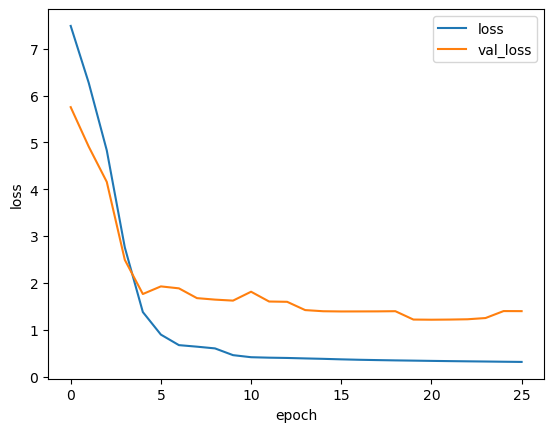

In [4]:
hist_big = pd.DataFrame(history_big.history)

plt.plot(hist_big.loss, label = "loss")
plt.plot(hist_big.val_loss, label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

In [5]:
model_tiny = tf.keras.Sequential([
        tf.keras.layers.Input(shape = (13)),
        tf.keras.layers.Dense(4, activation = 'relu'),
        tf.keras.layers.Dense(2, activation = 'relu'),
        tf.keras.layers.Dense(1)
])
model_tiny.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


history_tiny = model_tiny.fit(X_train, y_train, epochs = EPOCHS, validation_data=(X_val, y_val), callbacks = [es])
hist_tiny = pd.DataFrame(history_tiny.history)

Epoch 1/10000
6/6 [==============================] - 0s 22ms/step - loss: 3.1315 - accuracy: 0.4420 - val_loss: 2.2342 - val_accuracy: 0.5082
Epoch 2/10000
6/6 [==============================] - 0s 5ms/step - loss: 2.3261 - accuracy: 0.4420 - val_loss: 2.0252 - val_accuracy: 0.5082
Epoch 3/10000
6/6 [==============================] - 0s 5ms/step - loss: 2.1068 - accuracy: 0.4420 - val_loss: 1.9106 - val_accuracy: 0.5082
Epoch 4/10000
6/6 [==============================] - 0s 5ms/step - loss: 1.9921 - accuracy: 0.4420 - val_loss: 1.7698 - val_accuracy: 0.5082
Epoch 5/10000
6/6 [==============================] - 0s 5ms/step - loss: 1.9184 - accuracy: 0.4420 - val_loss: 1.6445 - val_accuracy: 0.5082
Epoch 6/10000
6/6 [==============================] - 0s 5ms/step - loss: 1.8564 - accuracy: 0.4420 - val_loss: 1.5926 - val_accuracy: 0.5082
Epoch 7/10000
6/6 [==============================] - 0s 5ms/step - loss: 1.8045 - accuracy: 0.4420 - val_loss: 1.5648 - val_accuracy: 0.5082
Epoch 8/1000

Epoch 59/10000
6/6 [==============================] - 0s 6ms/step - loss: 0.5819 - accuracy: 0.7569 - val_loss: 0.7117 - val_accuracy: 0.6557
Epoch 60/10000
6/6 [==============================] - 0s 5ms/step - loss: 0.5778 - accuracy: 0.7514 - val_loss: 0.7071 - val_accuracy: 0.6721
Epoch 61/10000
6/6 [==============================] - 0s 5ms/step - loss: 0.5736 - accuracy: 0.7514 - val_loss: 0.7017 - val_accuracy: 0.6721
Epoch 62/10000
6/6 [==============================] - 0s 5ms/step - loss: 0.5697 - accuracy: 0.7569 - val_loss: 0.6958 - val_accuracy: 0.6721
Epoch 63/10000
6/6 [==============================] - 0s 5ms/step - loss: 0.5653 - accuracy: 0.7624 - val_loss: 0.6909 - val_accuracy: 0.6721
Epoch 64/10000
6/6 [==============================] - 0s 4ms/step - loss: 0.5614 - accuracy: 0.7624 - val_loss: 0.6872 - val_accuracy: 0.6721
Epoch 65/10000
6/6 [==============================] - 0s 5ms/step - loss: 0.5581 - accuracy: 0.7569 - val_loss: 0.6841 - val_accuracy: 0.6721
Epoch 

6/6 [==============================] - 0s 5ms/step - loss: 0.4133 - accuracy: 0.8066 - val_loss: 0.5442 - val_accuracy: 0.7049
Epoch 117/10000
6/6 [==============================] - 0s 5ms/step - loss: 0.4110 - accuracy: 0.8066 - val_loss: 0.5438 - val_accuracy: 0.7049
Epoch 118/10000
6/6 [==============================] - 0s 5ms/step - loss: 0.4084 - accuracy: 0.8066 - val_loss: 0.5439 - val_accuracy: 0.7049
Epoch 119/10000
6/6 [==============================] - 0s 5ms/step - loss: 0.4064 - accuracy: 0.8066 - val_loss: 0.5441 - val_accuracy: 0.7049
Epoch 120/10000
6/6 [==============================] - 0s 5ms/step - loss: 0.4040 - accuracy: 0.8066 - val_loss: 0.5447 - val_accuracy: 0.7049
Epoch 121/10000
6/6 [==============================] - 0s 5ms/step - loss: 0.4022 - accuracy: 0.8066 - val_loss: 0.5448 - val_accuracy: 0.7049
Epoch 122/10000
6/6 [==============================] - 0s 5ms/step - loss: 0.4001 - accuracy: 0.8066 - val_loss: 0.5469 - val_accuracy: 0.7049


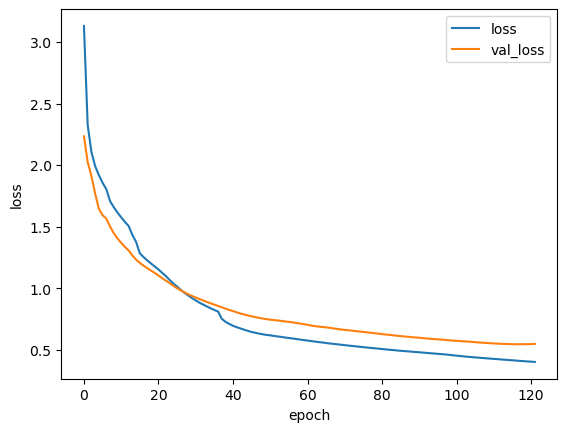

In [6]:
hist_tiny = pd.DataFrame(history_tiny.history)

plt.plot(hist_tiny.loss, label = "loss")
plt.plot(hist_tiny.val_loss, label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

In [7]:
output_tiny = model_tiny.evaluate(X_test, y_test)
output_big = model_big.evaluate(X_test, y_test)

2/2 [==============================] - 0s 4ms/step - loss: 1.5540 - accuracy: 0.7541
